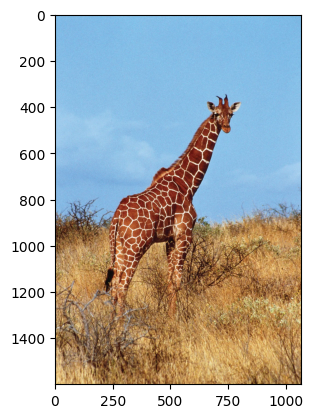

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread("giraffe.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# Color Histogram for RGB

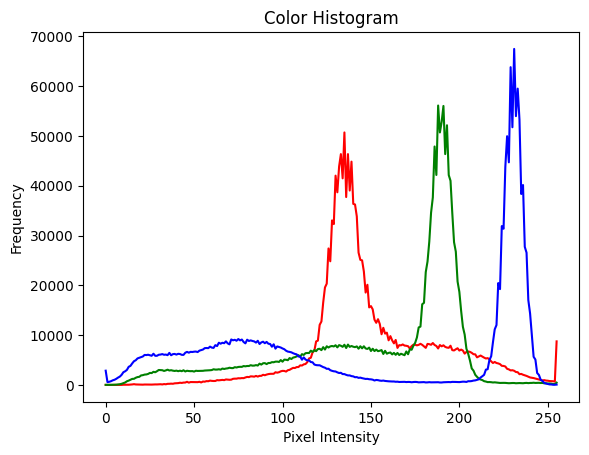

In [ ]:
r, g, b = cv2.split(img_rgb)
channels = [0]
mask = None
hist_size = [256]
ranges = [0, 256]

hist = cv2.calcHist([r], channels, mask, hist_size, ranges)
plt.plot(hist, color="red")
hist = cv2.calcHist([g], channels, mask, hist_size, ranges)
plt.plot(hist, color="green")
hist = cv2.calcHist([b], channels, mask, hist_size, ranges)
plt.plot(hist, color="blue")

plt.title("Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Color Histogram for HSV

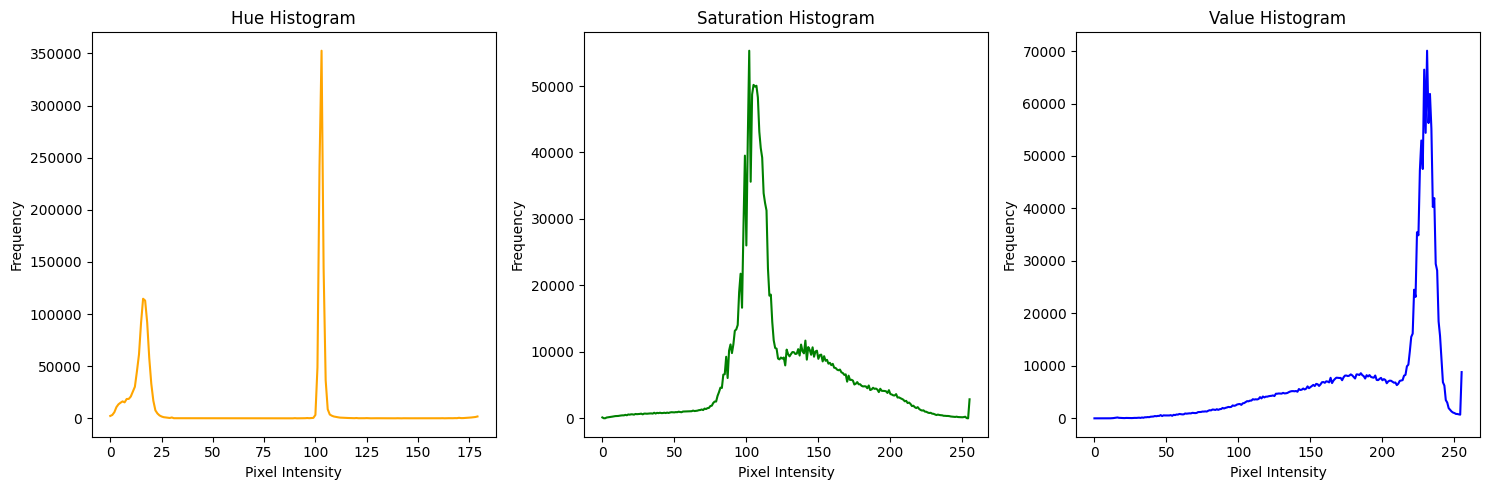

In [ ]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv_img)
channels = [0]
mask = None

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
hue_hist = cv2.calcHist([h], channels, mask, [180], [0, 180])
plt.plot(hue_hist, color="orange")
plt.title("Hue Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
saturation_hist = cv2.calcHist([s], channels, mask, [256], [0, 256])
plt.plot(saturation_hist, color="green")
plt.title("Saturation Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
value_hist = cv2.calcHist([v], channels, mask, [256], [0, 256])
plt.plot(value_hist, color="blue")
plt.title("Value Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Histogram Equalization

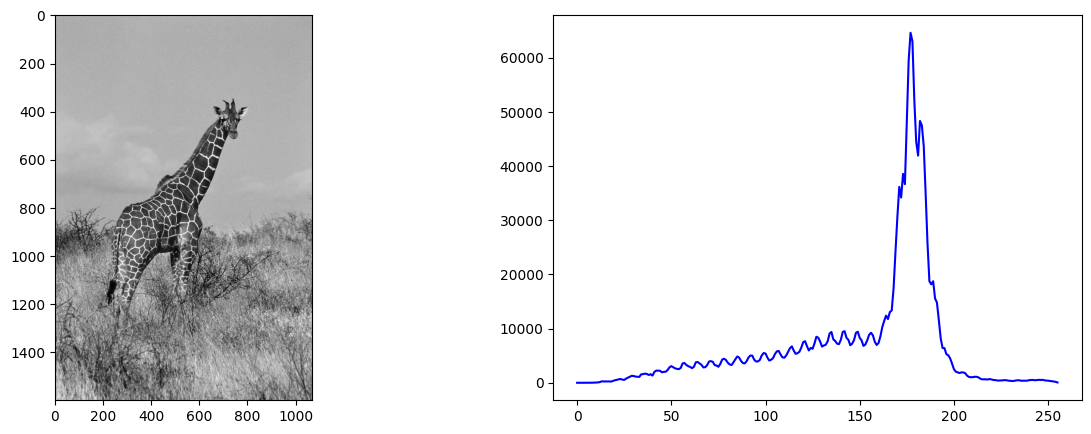

In [9]:
img_greyscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist, bins = np.histogram(img_greyscale.flatten(), 256, [0, 256])

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(img_greyscale, cmap="gray")
plt.subplot(1,2,2)
plt.plot(hist, color="blue")

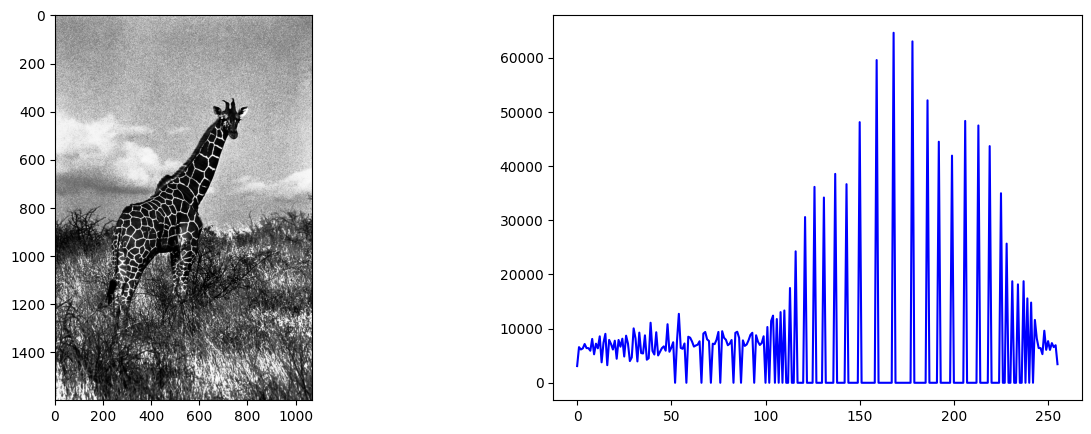

In [10]:
equalized_img = cv2.equalizeHist(img_greyscale)
equalized_hist, equalized_bins = np.histogram(equalized_img.flatten(), 256, [0, 256])

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(equalized_img, cmap="gray")
plt.subplot(1,2,2)
plt.plot(equalized_hist, color="blue")

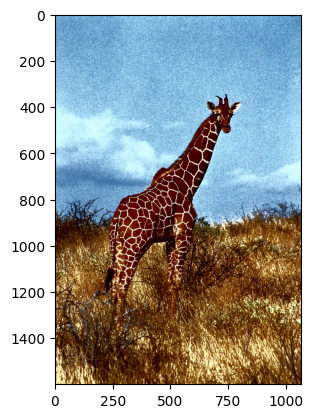

In [15]:
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
equalised_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

plt.imshow(equalised_img)

# CLAHE histogram equalization

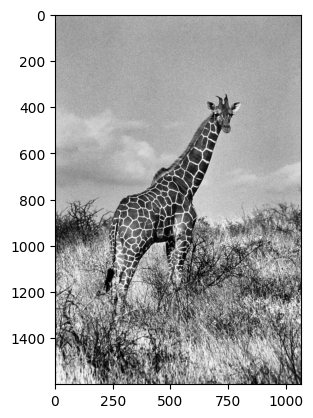

In [14]:
img_greyscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
clahe_equalized_img = clahe.apply(img_greyscale)

plt.imshow(clahe_equalized_img, cmap='grey')

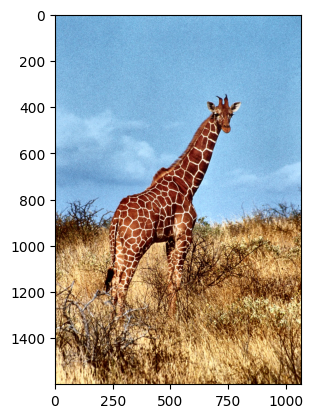

In [16]:
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
equalised_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

plt.imshow(equalised_img)